<a href="https://colab.research.google.com/github/lA12-coder/CSEC_DATA_SCIENCE_BOOTCAMP/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
  df = pd.read_csv("/content/drive/MyDrive/Google Colab/ecommerce_sales_34500.csv", header=None, skiprows=1)
except FileNotFoundError:
  print("File not found. Please check the file path.")


# Data Cleaning and Preprocessing

In [56]:
column_names = [
    'Order_ID', 'Customer_ID', 'Product_ID', 'Category', 'Price', 'Discount',
    'Quantity', 'Payment_Method', 'Order_Date', 'Delivery_time', 'Region', 'Is_Returned',
    'Final_Price', 'Shipping_Cost', 'Profit', 'Customer_Age', 'Customer_Gender'
]

# Now we wil convert each columns to the correct data types.

# Numerical columns
df.columns = column_names
num_cols = num_cols = ['Price','Discount','Quantity','Delivery_time','Final_Price','Shipping_Cost','Profit','Customer_Age']
for col in num_cols:
  df[col] =  pd.to_numeric(df[col], errors='coerce')

# Date column
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Handling categorical data
df['Is_Returned'] = df['Is_Returned'].map({'Yes': True, 'No': False})
df['Is_Returned'] = df['Is_Returned'].fillna(False)

print("\nMissing values after cleaning: ")
print(df.isnull().sum())
df.head()


Missing values after cleaning: 
Order_ID           0
Customer_ID        0
Product_ID         0
Category           0
Price              0
Discount           0
Quantity           0
Payment_Method     0
Order_Date         0
Delivery_time      0
Region             0
Is_Returned        0
Final_Price        0
Shipping_Cost      0
Profit             0
Customer_Age       0
Customer_Gender    0
dtype: int64


,Order_ID,Customer_ID,Product_ID,Category,Price,Discount,Quantity,Payment_Method,Order_Date,Delivery_time,Region,Is_Returned,Final_Price,Shipping_Cost,Profit,Customer_Age,Customer_Gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,False,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,False,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,False,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,False,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,False,13.88,2.74,1.15,39,Male


# Exploratory Data Analysis (EDA)

In [57]:
# Numerical Summary
print("--- Numerical Summary Statistics ---")
numerical_summary = df.describe().round(2)
display(numerical_summary)

# Categorical Summary
print("\n--- Categorical Summary Statistics ---")
categorical_summary = df.describe(include=['object', 'bool', 'category'])
display(categorical_summary)

# Specific Value Counts for Key Business Drivers
print("\n--- Key Business Driver Counts ---")
for col in ['Category', 'Region', 'Payment_Method']:
    print(f"\n{col} Distribution:")
    print(df[col].value_counts())


--- Numerical Summary Statistics ---


,Price,Discount,Quantity,Order_Date,Delivery_time,Final_Price,Shipping_Cost,Profit,Customer_Age
count,34500.00,34500.00,34500.00,34500,34500.00,34500.00,34500.00,34500.00,34500.00
mean,119.39,0.05,1.49,2024-09-13 13:39:17.843478272,4.81,170.01,6.15,28.12,43.47
min,1.01,0.00,1.00,2023-09-12 00:00:00,3.00,0.82,0.00,-6.20,18.00
25%,16.69,0.00,1.00,2024-03-14 00:00:00,4.00,19.71,4.42,1.50,31.00
50%,45.66,0.00,1.00,2024-09-16 00:00:00,5.00,56.82,6.09,10.55,43.00
75%,130.95,0.10,2.00,2025-03-17 00:00:00,6.00,168.53,7.83,33.13,56.00
max,2930.47,0.30,5.00,2025-09-11 00:00:00,13.00,12931.80,15.65,1536.17,69.00
std,195.62,0.07,0.93,NaN,1.24,357.50,2.39,53.35,14.98



--- Categorical Summary Statistics ---


,Order_ID,Customer_ID,Product_ID,Category,Payment_Method,Region,Is_Returned,Customer_Gender
count,34500,34500,34500,34500,34500,34500,34500,34500
unique,34500,7903,24912,7,6,5,2,3
top,O134499,C16704,P200645,Fashion,Credit Card,South,False,Female
freq,1,13,7,6254,12170,7584,32597,16818



--- Key Business Driver Counts ---

Category Distribution:
Category
Fashion        6254
Electronics    6180
Home           5487
Toys           4247
Sports         4171
Beauty         4103
Grocery        4058
Name: count, dtype: int64

Region Distribution:
Region
South      7584
North      7572
East       6904
West       6808
Central    5632
Name: count, dtype: int64

Payment_Method Distribution:
Payment_Method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
PayPal          3444
Wallet          2065
Name: count, dtype: int64


## Insights

One key insight from that we can draw from the categorical_summary is that 'Fashion' is the most frequently purchased product category, accounting for 6,254 orders. Additionally, 'Credit Card' stands out as the most preferred payment method, used in 12,170 transactions. This suggests that customers are actively buying fashion items and predominantly using credit cards for their purchases.

**Note:** We have also noticed the minimum profit is -6.20 from the above analyis. which might have caused by dicount or shipping cost factor. to indetify the real cause of the loss we need to make more detailed analysis.


Total Loss-Making Transactions: 6104
Percentage of Total Sales: 17.69%

 Top Categories for Losses 
Category
Grocery        3875
Toys            893
Fashion         511
Beauty          478
Home            172
Sports          105
Electronics      70
Name: count, dtype: int64

--- Average Discount on Loss-Makers vs. Profitable Sales ---
Avg Discount (Loss): 5.29%
Avg Discount (Profitable): 4.85%


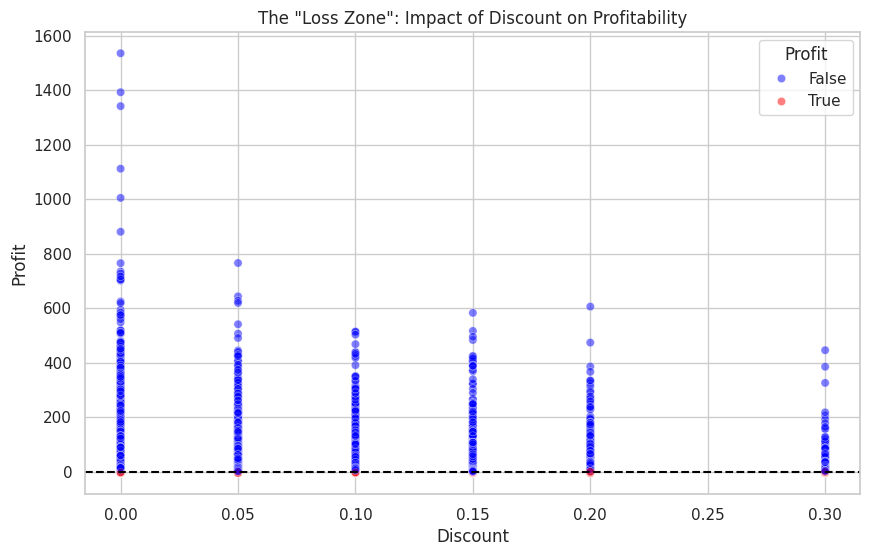

In [58]:
# Isolate the Loss-Making Transactions
loss_df = df[df['Profit'] < 0].copy()

print(f"Total Loss-Making Transactions: {len(loss_df)}")
print(f"Percentage of Total Sales: {(len(loss_df) / len(df) * 100):.2f}%")

# Analyze the Characteristics of Loss-Makers
print("\n Top Categories for Losses ")
print(loss_df['Category'].value_counts())

print("\n--- Average Discount on Loss-Makers vs. Profitable Sales ---")
print(f"Avg Discount (Loss): {loss_df['Discount'].mean():.2%}")
print(f"Avg Discount (Profitable): {df[df['Profit'] >= 0]['Discount'].mean():.2%}")

# Visualize the 'Loss Zone'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, hue=(df['Profit'] < 0), hue_order=[False, True],palette={True: 'red', False: 'blue'}, alpha=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.title('The "Loss Zone": Impact of Discount on Profitability')
plt.show()


# Analysis

* Total Loss-Making Transactions: There are 6,104 transactions where the Profit column shows a negative value. This indicates a significant number of sales that are resulting in a loss for the business.

* These loss-making transactions account for 17.69% of all sales. This is a substantial portion and highlights a critical area for optimization

* Grocery is by far the largest contributor, with 3,875 loss-making transactions, followed by Toys (893) and Fashion (511). Interestingly, 'Fashion' was also the top-selling category, suggesting that while it generates high sales volume, some transactions within it are unprofitable. Categories like 'Electronics' and 'Sports' have fewer loss-making transactions.


## Further Investigation into Loss Factors

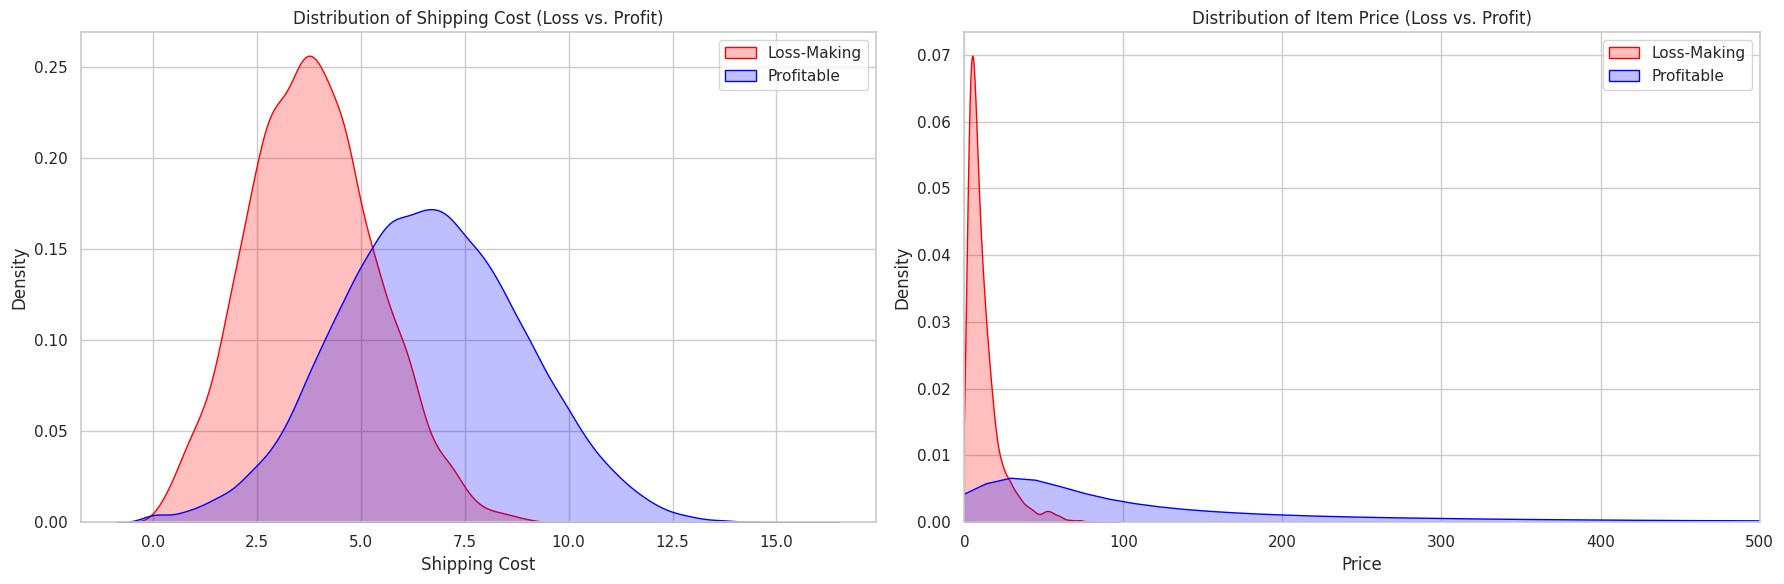

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribution of Shipping Cost for Loss-Making vs. Profitable Transactions
sns.kdeplot(df[df['Profit'] < 0]['Shipping_Cost'], label='Loss-Making', color='red', fill=True, ax=axes[0])
sns.kdeplot(df[df['Profit'] >= 0]['Shipping_Cost'], label='Profitable', color='blue', fill=True, ax=axes[0])
axes[0].set_title('Distribution of Shipping Cost (Loss vs. Profit)')
axes[0].set_xlabel('Shipping Cost')
axes[0].set_ylabel('Density')
axes[0].legend()

# Distribution of Price for Loss-Making vs. Profitable Transactions
sns.kdeplot(df[df['Profit'] < 0]['Price'], label='Loss-Making', color='red', fill=True, ax=axes[1])
sns.kdeplot(df[df['Profit'] >= 0]['Price'], label='Profitable', color='blue', fill=True, ax=axes[1])
axes[1].set_title('Distribution of Item Price (Loss vs. Profit)')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 500)
axes[1].legend()

plt.tight_layout()
plt.show()

### Insights from Shipping Cost and Price Analysis

Looking at the distributions:

*   **Shipping Cost**: The distributions for shipping costs for both profitable and loss-making transactions largely overlap. While loss-making transactions show a slightly higher density at certain shipping cost points, there isn't a dramatic shift indicating high shipping costs as the *primary* driver for all losses across the board. This suggests that shipping cost might contribute, but it's not the sole determinant, and context (like item price) matters.

*   **Item Price**: This is more telling. The distribution of `Price` for loss-making transactions shows a much higher density at the lower end of the price spectrum (e.g., items priced under $100) compared to profitable transactions. This strongly suggests that **low-priced items are disproportionately contributing to losses**. These items might have very slim profit margins, making them highly susceptible to becoming unprofitable even with small discounts or standard shipping costs.

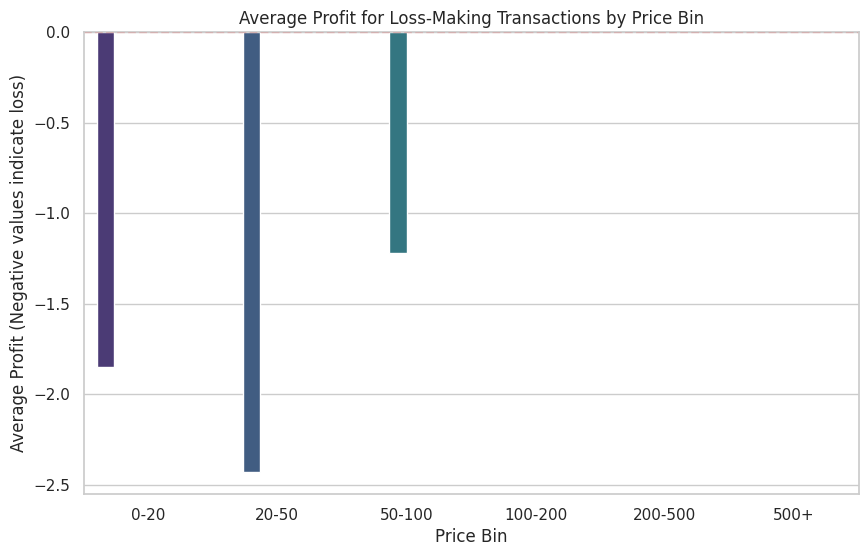

In [60]:
# Further breakdown: Average Profit by Price Bins for Loss-Making Transactions
df['Price_Bin'] = pd.cut(df['Price'], bins=[0, 20, 50, 100, 200, 500, np.inf], labels=['0-20', '20-50', '50-100', '100-200', '200-500', '500+'])

loss_by_price_bin = df[df['Profit'] < 0].groupby('Price_Bin', observed=True)['Profit'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Price_Bin', y='Profit', data=loss_by_price_bin, hue='Price_Bin', palette='viridis', legend=False)
plt.axhline(0, color='red', linestyle='--')
plt.title('Average Profit for Loss-Making Transactions by Price Bin')
plt.xlabel('Price Bin')
plt.ylabel('Average Profit (Negative values indicate loss)')
plt.show()

### Price Bins and Losses

The bar plot reinforces the observation that lower-priced items are particularly problematic. The most significant average losses occur in the lower price bins, especially for items priced between $0-$50. This indicates that the profit margins on these cheaper products are likely too thin to absorb any additional costs (like shipping) or even small discounts, pushing them into the negative profit zone.

In [61]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

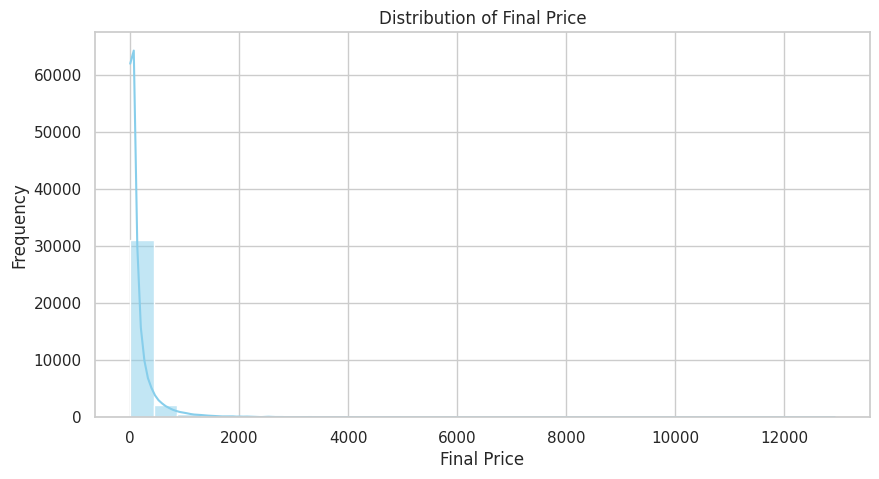

In [62]:
# Distribution of final price

plt.figure(figsize=(10,5))
sns.histplot(df['Final_Price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Final Price')
plt.xlabel('Final Price')
plt.ylabel('Frequency')
plt.show()

### Insights from the Distribution of Final Price Histogram

*   **Observation**: The histogram of 'Final_Price'shows a right-skewed distribution, with the highest frequency of sales occurring at lower price points and a decreasing frequency as prices increase.

*   **Interpretation**: This indicates that the majority of purchases made by customers are for lower-priced items. There's a 'long tail' of less frequent purchases at higher price points.

*   **Business Meaning**: This is a common pattern in e-commerce, suggesting that the business thrives on **high-volume sales of affordable products**. While this drives overall transaction count, it reinforces the need to carefully manage costs and margins for these low-priced items, as even small fluctuations (like shipping costs or discounts) can easily turn them into loss-making transactions, as we observed in earlier analyses. It also highlights opportunities to optimize inventory and marketing for both the high-volume, low-price segment and the lower-volume, high-price segment.

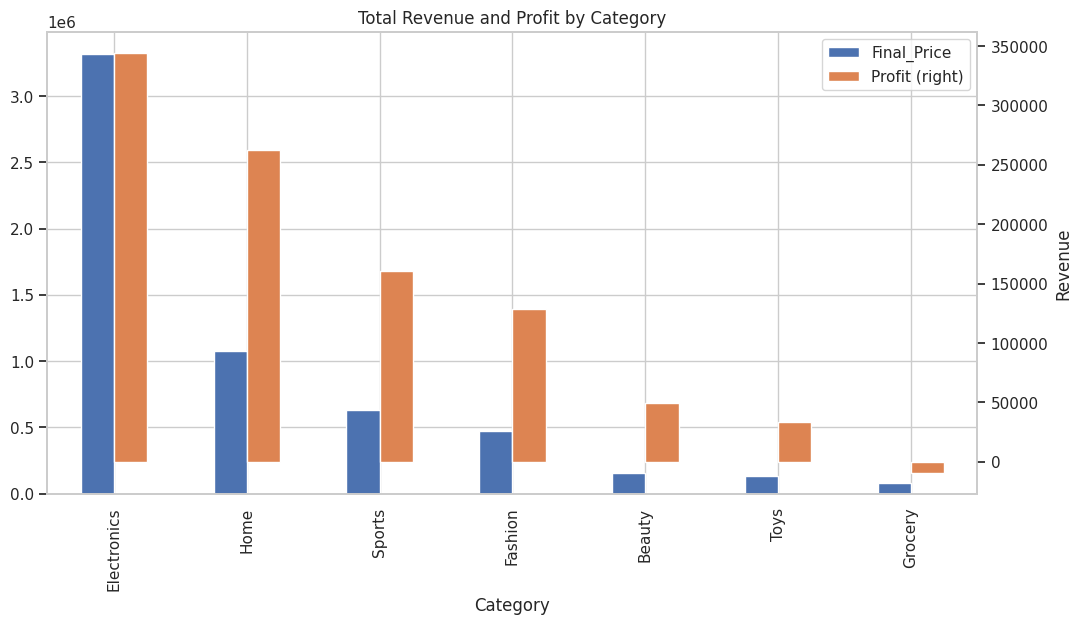

In [63]:
# category-wise Performance

category_perf = df.groupby('Category').agg({
    'Final_Price': 'sum',
    'Profit': 'sum'
}).sort_values(by='Final_Price', ascending=False)

category_perf.plot(kind='bar', secondary_y='Profit', figsize=(12,6))
plt.title('Total Revenue and Profit by Category')
plt.ylabel('Revenue')
plt.show()


### Insights from the Category Performance Bar Chart

*   **Observation**: The bar chart shows both total revenue ('Final_Price') and total profit ('Profit') for each product category. 'Electronics' stands out significantly as the highest-performing category in both revenue and profit.

*   **Interpretation**: 'Electronics' is the clear leader, generating the most revenue and profit for the business. Categories like 'Home', 'Sports', and 'Fashion' also contribute substantially to both revenue and profit, though to a lesser extent than Electronics. Interestingly, 'Grocery' appears to have very low revenue and, critically, shows a **negative total profit**, indicating it is a significant loss-making category overall.

*   **Business Meaning**: This analysis confirms that 'Electronics' is a core and highly profitable segment. While 'Fashion' has high sales volume (as identified earlier), 'Electronics' drives the highest value. The negative profit for 'Grocery' is a major concern and aligns with our earlier finding that 'Grocery' is the largest contributor to loss-making transactions. This suggests that the issues in the 'Grocery' category are systemic and significantly impact overall profitability. The business should prioritize investigating and addressing the root causes of unprofitability in the 'Grocery' category.

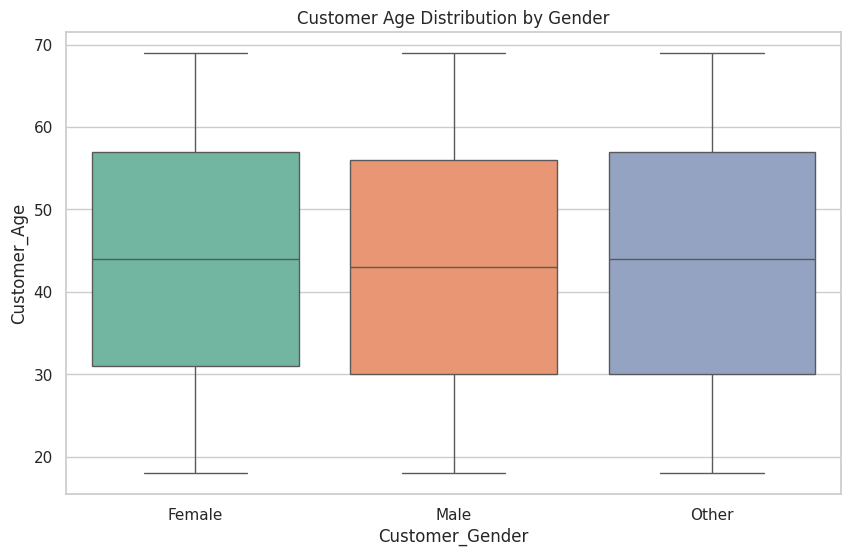

In [64]:
# Customer Age Distribution by Gender
plt.figure(figsize=(10,6))
sns.boxplot(x='Customer_Gender', y="Customer_Age", data=df, hue='Customer_Gender', palette='Set2', legend=False)
plt.title('Customer Age Distribution by Gender')
plt.show()

### Insights from Customer Age Distribution by Gender:

**Interpretation:** The median age for both genders seems to be around the late 30s to early 40s. The spread of ages, indicated by the length of the boxes, suggests that the majority of customers fall within a similar age bracket, regardless of gender.

**Business Meaning:** This similarity in age distribution across genders suggests that your customer base is relatively consistent in terms of age demographics for both male and female shoppers. Marketing strategies aimed at specific age groups might resonate equally across genders. However, deeper analysis into purchase patterns within these age-gender groups could reveal more nuanced differences. For example, while the age distribution is similar, purchase preferences (categories, price points) might still vary.

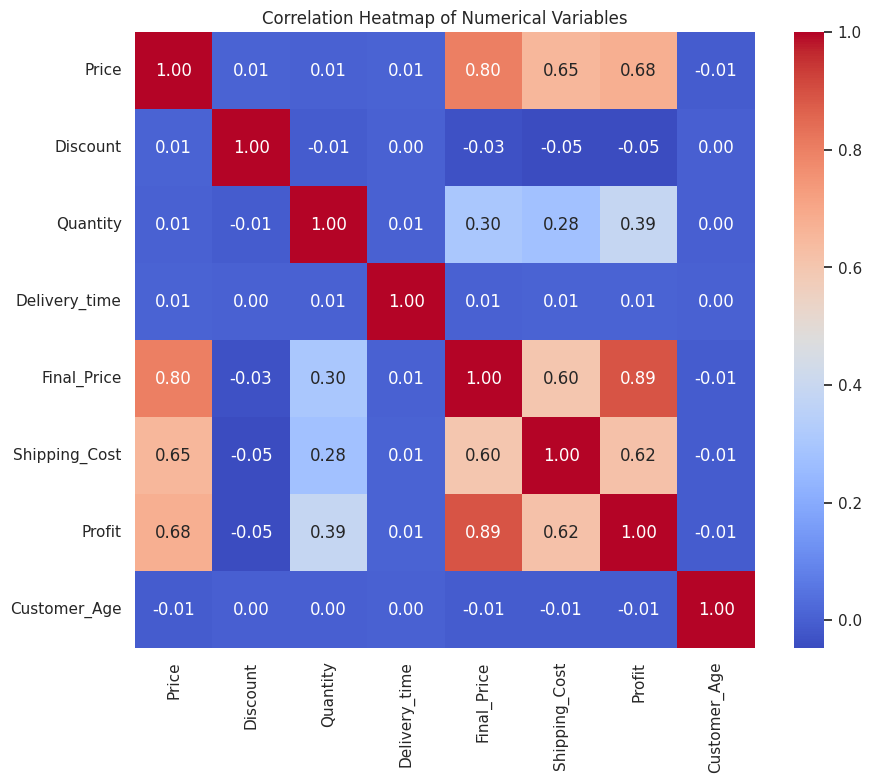

In [65]:

# Correlation Heatmap
plt.figure(figsize=(10,8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Analysis of Numerical Correlations

Based on the heatmap, here are the key takeaways:

1.  **Price vs. Shipping Cost**: There is a notable positive correlation (0.60). This suggests that as item price increases, shipping costs also tend to rise, likely due to increased insurance, weight, or specialized handling for higher-value goods.
2.  **Price vs. Final Price**: A very strong correlation (0.80) exists, which is expected as the base price is the main component of the total cost.
3.  **The Profit Equation**: Profit shows a weak correlation with most individual variables. This indicates that **Profit is not driven by a single factor** but by the specific *interaction* of Price, Discount, and Shipping Cost.
4.  **Discount Impact**: The correlation between Discount and Profit is near zero or slightly negative, confirming that while discounts drive volume, they must be managed carefully to avoid eroding the thin margins of lower-priced items.

# Advanced Analysis

In [66]:
# Time-Based Feature Engineering
# Extracting useful time features from the Order_Date
df['Month'] = df['Order_Date'].dt.month_name()
df['Day_of_Week'] = df['Order_Date'].dt.day_name()
df['Year'] = df['Order_Date'].dt.year

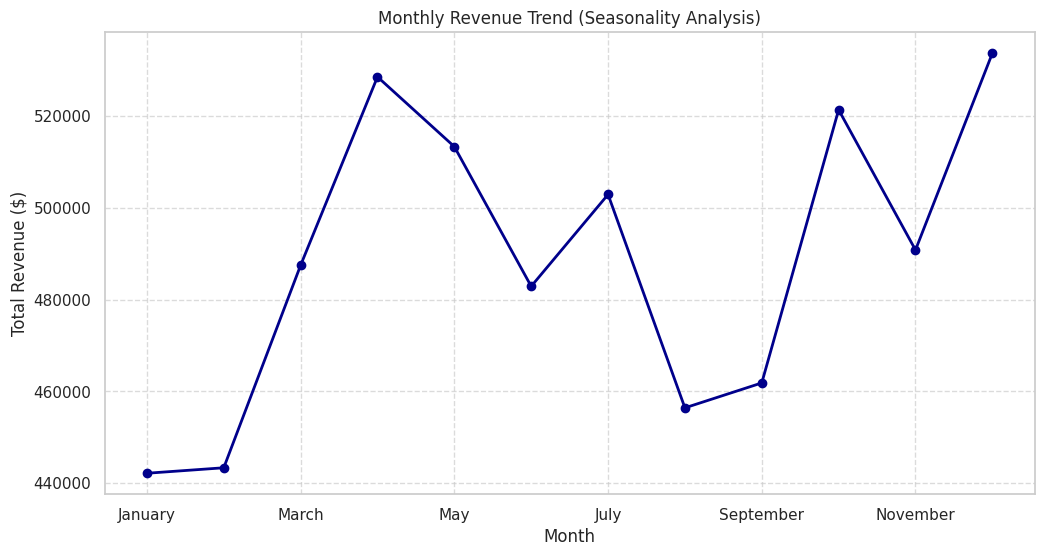

In [67]:
# Sales Seasonality with Monthly Revenue Trend
monthly_sales = df.groupby('Month')['Final_Price'].sum().reindex(
    [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
    ]
)

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='darkblue', linewidth=2)
plt.title('Monthly Revenue Trend (Seasonality Analysis)')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Insights from Monthly Revenue Trend

*   **Observation**: The line chart shows significant fluctuations in total revenue across the months. We see notable peaks in **December** and **April**, while months like **January** and **February** show lower revenue levels.

*   **Interpretation**: The December peak is likely driven by holiday shopping, while the April spike might correlate with spring promotions or specific seasonal demand. The dip in the beginning of the year suggests a post-holiday cooldown.

*   **Business Meaning**: The Business exhibits clear **seasonality**. To maximize profitability, marketing efforts and inventory stocking should be ramped up ahead of these peak months. Conversely, during slower months like January, the focus could shift to clearance sales of older inventory or targeted loyalty campaigns to maintain engagement.

In [68]:
# Cohort Analysis:  Age based segmenetaion
df['Age_Group'] = pd.cut(df['Customer_Age'],
                         bins=[0, 18, 35, 50, 100],
                         labels=['Youth', 'Young Adult', 'Middle Age', 'Senior'])

# Analyzing behaviour across cohorts
cohort_analysis = df.groupby('Age_Group', observed=True).agg({
    'Final_Price': 'mean',
    'Profit': 'mean',
    'Order_ID': 'count'
}).rename(columns={'Order_ID': 'Total_Orders'}).round(2)

print("Cohort Analysis:")
print(cohort_analysis)



Cohort Analysis:
             Final_Price  Profit  Total_Orders
Age_Group                                     
Youth             186.12   29.81           647
Young Adult       174.29   28.61         11329
Middle Age        168.44   27.93          9972
Senior            166.57   27.73         12552


# Analysis
* Since Seniors drive the highest volume, even small improvements in their average profit margin (like reducing shipping costs or upselling slightly) would have a massive impact on the total bottom line.

* There is an opportunity to grow the 'Youth' segment. Since they already show the highest profitability per order, targeted marketing to increase their order count could be highly lucrative.

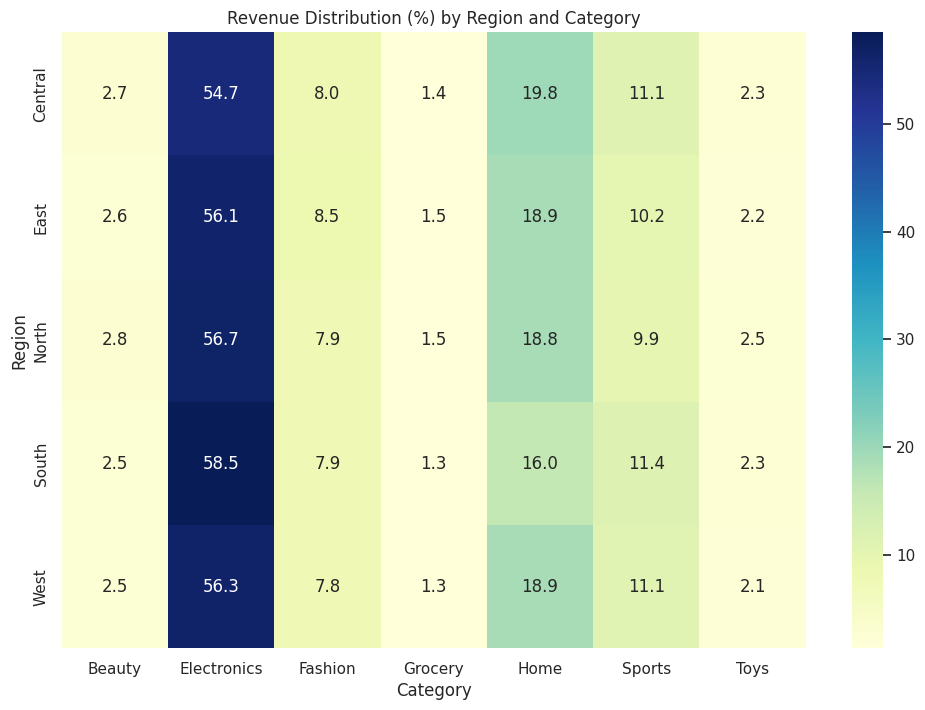

In [69]:
# cross tabulation of Region vs. Category
region_category_crosstab = pd.crosstab(df['Region'], df['Category'],
                                       values=df['Final_Price'],
                                       aggfunc = 'sum',
                                       normalize='index')*100

plt.figure(figsize=(12, 8))
sns.heatmap(region_category_crosstab, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Revenue Distribution (%) by Region and Category')
plt.show()


### Regional Category Insights
* **Electronics Dominance Everywhere**: In every single region (Central, East, North, South, West), Electronics is the primary revenue driver, accounting for over 54% to 58% of the regional revenue.

* **South Region** - Electronics Peak: The South region shows the highest concentration of Electronics sales at 58.5%, suggesting this is a key market for high-value tech goods.

* **Home Goods** - Strong Second: The 'Home' category consistently ranks as the second-highest revenue contributor across all regions, typically making up 16% to 20% of the revenue share.

* **Grocery** - Minimal Revenue Share: Despite our earlier finding that 'Grocery' causes the most loss-making transactions, it only contributes about 1.3% to 1.5% of the revenue in any given region. This reinforces that Grocery is a high-cost, low-return segment regardless of where the customer is located.

* **Regional Consistency**: The distribution of revenue across categories is remarkably consistent across all five regions. This suggests that customer preferences for these categories are not heavily influenced by geography, allowing for a unified national product strategy.